# POF Plotter

Importing all the necessary python libraries

In [12]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import xarray as xr
import matplotlib as mpl
from cartopy import config
import cartopy.crs as ccrs
import cartopy as cart
import sys
import datetime
from matplotlib.colors import ListedColormap,LinearSegmentedColormap


Open Prediction Netcdf

In [13]:
fire= xr.open_dataset("./outputs/POF_prediction_2003_01.nc")
lats = fire.lat.values
lons = fire.lon.values


Define a subregion to plot

In [45]:
lat1 = 0.0
lat2 = 55.0
lon1 = -20
lon2 = 50
x1 = (np.argmin(np.abs(lons - lon1)))
x2 = (np.argmin(np.abs(lons - lon2)))
y1 = (np.argmin(np.abs(lats - lat1)))
y2 = (np.argmin(np.abs(lats - lat2)))

sub_lons = lons[x1:x2]
sub_lats = lats[y1:y2]



Create colour pallete

In [46]:
cols = ['#4a5a60','#edcc00','#edcc00','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e21819','#e21819','#e21819','#e21819','#e21819','#000000','#000000']
test = ListedColormap(cols)

Define levels

In [51]:
fires = fire.fire_probability.squeeze()[0,y1:y2,x1:x2].values

fires[fires>0.006]=0.006 # 1km

levels = np.arange(16)/2500 # 1km

print(np.shape(fires))
print(np.shape(sub_lons))
print(np.shape(sub_lats))
print(np.nanmax(fire.fire_probability.values))
print(np.nanmin(fire.fire_probability.values))
print(np.nanmean(fire.fire_probability.values))

(55, 50)
(50,)
(55,)
0.9858961701393127
8.52175071486272e-06
0.00299337755630358


Plot

/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


[Text(1, 0.0002, 'Low'),
 Text(1, 0.0008, 'Medium'),
 Text(1, 0.0022, 'High'),
 Text(1, 0.0044, 'Very High'),
 Text(1, 0.0056, 'Extreme')]

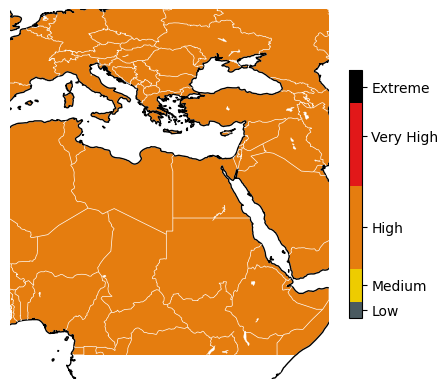

In [48]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

fig = ax.contourf(sub_lons, sub_lats, fires,levels=levels,vmin=0,vmax=0.006,transform=ccrs.PlateCarree(),cmap=test)

ax.add_feature(cart.feature.OCEAN,zorder=1,edgecolor='k',color='white')
ax.add_feature(cart.feature.BORDERS,linewidth=0.5,color='white')
ax.add_feature(cart.feature.LAKES,color='white', edgecolor='k', linewidth=0.2, zorder=2)

states_provinces = cart.feature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        edgecolor='black',
        facecolor='none'
)

for spine in ax.spines.values():
   spine.set_visible(False)

cbar = plt.colorbar(fig,ticks=[0.0002,0.0008,0.0022,0.0044,0.0056],fraction=0.025, pad=0.04)
cbar.ax.set_yticklabels(['Low', 'Medium','High', 'Very High', 'Extreme'])



Save Plot

In [11]:
plt.tight_layout()

plt.savefig('My_PoF_Plot.png', dpi=300)

<Figure size 640x480 with 0 Axes>